In [1]:
# Importing
from __future__ import annotations
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.io import mmread
import os
import time
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [2]:
np.random.seed(42)

In [3]:
runtime_log = []
def timed(name, func):
    start = time.time()
    result = func()
    end = time.time()
    runtime_log.append((name, end - start))
    print(f"{name}: {end - start:.2f} sec")
    return result

In [4]:
adata = sc.read_10x_mtx("GSM9195629_rep1/", var_names='gene_symbols')
print(adata)

AnnData object with n_obs × n_vars = 6068 × 32285
    var: 'gene_ids', 'feature_types'


In [5]:
adata.uns["project"] = "pcl_injury"
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)


In [6]:
print(adata)  # matches Seurat Dataset filtering

AnnData object with n_obs × n_vars = 6045 × 22240
    obs: 'n_genes'
    var: 'gene_ids', 'feature_types', 'n_cells'
    uns: 'project'


In [7]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

timed("QC metrics", lambda: sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
))

QC metrics: 1.45 sec


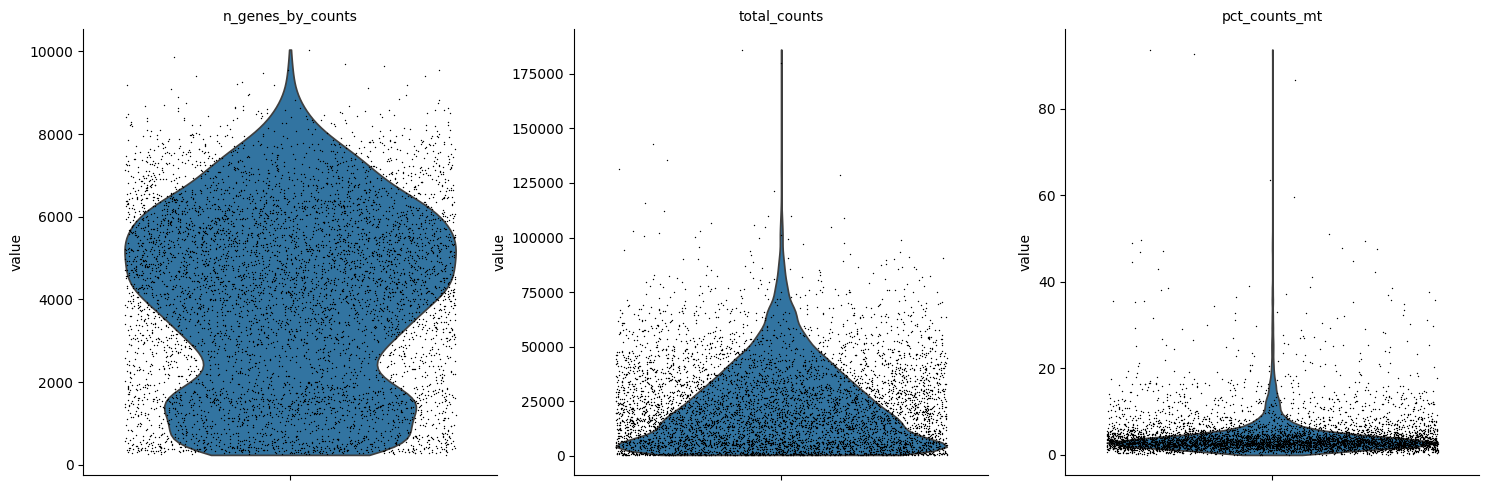

In [8]:
# QC plots
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    show=False
)

<Axes: title={'center': 'pct counts mt'}, xlabel='total_counts', ylabel='n_genes_by_counts'>

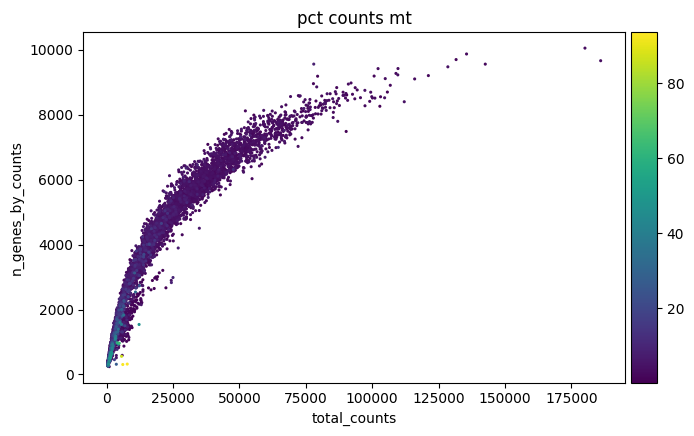

In [9]:
sc.pl.scatter(
    adata,
    "total_counts",
    "n_genes_by_counts",
    color="pct_counts_mt",
    show=False
)

In [8]:
# QC filtering
adata = timed("Filter by QC", lambda: adata[
    (adata.obs["n_genes_by_counts"] > 1000) &
    (adata.obs["n_genes_by_counts"] < 7000) &
    (adata.obs["total_counts"] < 50000) &
    (adata.obs["pct_counts_mt"] < 10)
].copy())


Filter by QC: 0.24 sec


In [9]:
adata.layers["counts"] = adata.X.copy()

timed("Normalize", lambda: sc.pp.normalize_total(adata, target_sum=1e4))
timed("Log1p", lambda: sc.pp.log1p(adata))


Normalize: 4.32 sec
Log1p: 0.15 sec


In [10]:
# HVG
# Remove unwanted genes before HVG selection
mask = ~adata.var_names.str.startswith(('Hb', 'Rpl', 'Rps'))
adata = adata[:, mask].copy()
print("After gene filtering:", adata.shape)

# HVG selection
timed("HVG", lambda: sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat_v3",
    layer="counts"
))

print("HVGs after selection:", adata.var['highly_variable'].sum())

After gene filtering: (4551, 22134)
HVG: 1.87 sec
HVGs after selection: 2000


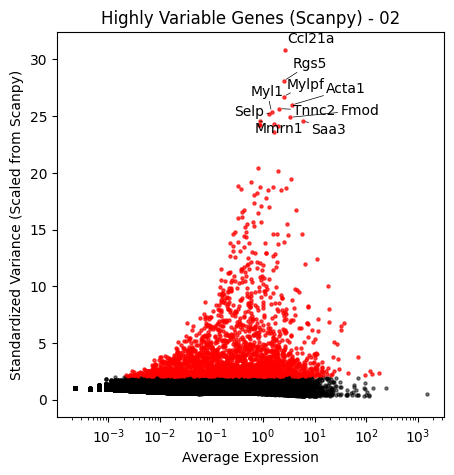

In [12]:
# Plotting HVG
means = adata.var["means"]
var = adata.var["variances_norm"]
hvg = adata.var["highly_variable"]

plt.figure(figsize=(5, 5))

# Non-variable genes
plt.scatter(means[~hvg], var[~hvg], s=5, color="black", alpha=0.5)

# HVGs
plt.scatter(means[hvg], var[hvg], s=5, color="red", alpha=0.7)

plt.xscale("log")
plt.xlabel("Average Expression")
plt.ylabel("Standardized Variance (Scaled from Scanpy)")

#plt.legend([
#    f"Non-variable count: {(~hvg).sum()}",
#    f"Variable count: {hvg.sum()}"
#])

plt.title("Highly Variable Genes (Scanpy) - 02")

# Top genes
top_genes = adata.var[adata.var["highly_variable"]] \
    .sort_values("variances_norm", ascending=False) \
    .head(10)

texts = []

for gene in top_genes.index:
    x = adata.var.loc[gene, "means"]
    y = adata.var.loc[gene, "variances_norm"]

    texts.append(plt.text(x, y, gene, fontsize=10))

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="black", lw=0.5),
)

plt.savefig("scanpy_02/hvg_scanpy_02.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# HVG
scanpy_hvg = adata.var_names[adata.var["highly_variable"]]
# simple list
pd.Series(list(scanpy_hvg)).to_csv("scanpy_02/scanpy_hvg_02.csv", index=False, header=False)


In [15]:
# Scaling
adata = adata[:, adata.var["highly_variable"]].copy()

timed("Scaling", lambda: sc.pp.scale(
    adata,
    zero_center=True,
    max_value=10
))

Scaling: 0.92 sec


c:\Users\sabri\AppData\Local\Programs\Python\Python313\Lib\functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [16]:
# PCA
timed("PCA", lambda: sc.tl.pca(
    adata,
    n_comps=50,
    use_highly_variable=True,
    svd_solver="arpack",
    random_state=42
))

C:\Users\sabri\AppData\Local\Temp\ipykernel_3120\3891419277.py:2: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  timed("PCA", lambda: sc.tl.pca(


PCA: 1.86 sec


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

loadings = adata.varm["PCs"]

# Select PC1 [0] or PC2 [1]
pc = loadings[:, 0]
genes = adata.var_names

df = pd.DataFrame({
    "gene": genes,
    "loading": pc
})

df["abs_loading"] = df["loading"].abs()

df_plot = df.sort_values("abs_loading", ascending=False).head(20)

df_plot = df_plot.sort_values("loading")

# Plot
plt.figure(figsize=(6,5))

plt.scatter(
    df_plot["loading"],
    df_plot["gene"],
    s=60   # dot size
)

plt.axvline(0, linestyle="--")
plt.xlabel("Loading")
plt.title("PC1 Loadings")

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig("scanpy_02/pc1_loadings_dotplot_02.png", dpi=300)
plt.close()

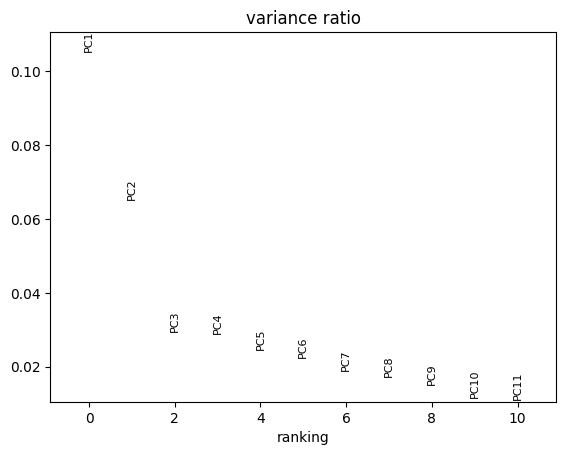

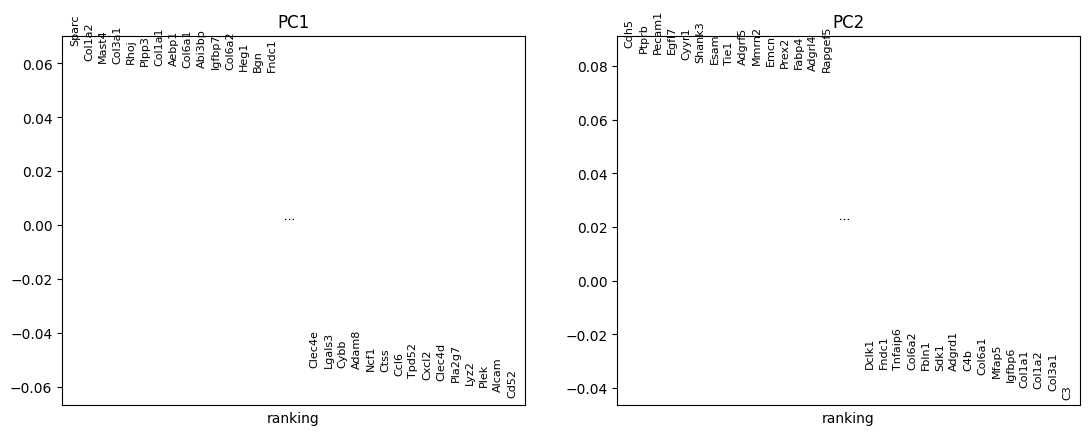

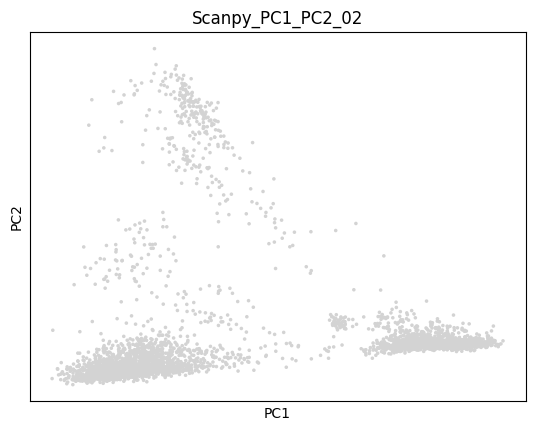

In [19]:
sc.pl.pca_variance_ratio(adata, log=False, n_pcs=10)
sc.pl.pca_loadings(adata, components="1,2")
adata.obsm["X_pca"][:, 0] *= -1
sc.pl.pca(
    adata,
    title="Scanpy_PC1_PC2_02",
)



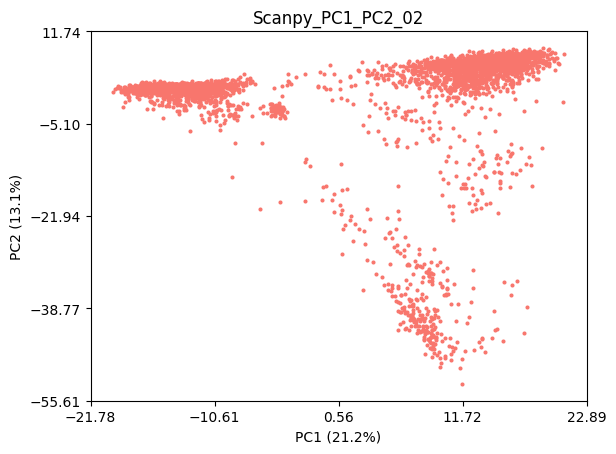

In [23]:
# Flip to match Seurat
adata.obsm["X_pca"][:, 0] *= 1
adata.obsm["X_pca"][:, 1] *= -1

sc.pl.pca(
    adata,
    color=None,
    size=15,
    title="Scanpy_PC1_PC2_02",
    show=False
)

ax = plt.gca()

ax.set_xticks(np.linspace(*ax.get_xlim(), 5))
ax.set_yticks(np.linspace(*ax.get_ylim(), 5))

ax.collections[0].set_color("#F8766D")

# Get variance explained
var_exp =  adata.uns["pca"]["variance"] / adata.uns["pca"]["variance"].sum()

# Label axes with percentages
ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")


plt.savefig("scanpy_02/pca_pc1_pc2_scanpy_02.png", dpi=300)
plt.show()

In [24]:
pca_embeddings = timed(
    "Embedding extraction",
    lambda: adata.obsm["X_pca"][:, :2]
)

pd.DataFrame(
    pca_embeddings,
    columns=["PC1", "PC2"]
).to_csv("scanpy_02/scanpy_pca_embeddings_02.csv", index=False)

Embedding extraction: 0.00 sec


In [25]:
adata.uns["pca"]["variance_ratio"].sum()

np.float64(0.4980080560733487)

In [26]:
var_explained = timed(
    "Variance explained",
    lambda: adata.uns["pca"]["variance"] / adata.uns["pca"]["variance"].sum()
)

variance_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(var_explained))],
    "Variance": var_explained
})

variance_df.to_csv("scanpy_02/scanpy_variance_explained_02.csv", index=False)

Variance explained: 0.00 sec


In [27]:
loadings = timed(
    "Loadings extraction",
    lambda: adata.varm["PCs"]
)

Loadings extraction: 0.00 sec


In [28]:
def compute_top_genes():
    pc1_vals = np.abs(loadings[:, 0])
    pc2_vals = np.abs(loadings[:, 1])

    top_pc1_idx = np.argsort(pc1_vals)[::-1][:10]
    top_pc2_idx = np.argsort(pc2_vals)[::-1][:10]

    pc1_df = pd.DataFrame({
        "Gene": adata.var_names[top_pc1_idx],
        "Loading": pc1_vals[top_pc1_idx]
    })

    pc2_df = pd.DataFrame({
        "Gene": adata.var_names[top_pc2_idx],
        "Loading": pc2_vals[top_pc2_idx]
    })

    pc1_df.to_csv("scanpy_02/scanpy_pc1_genes_02.csv", index=False)
    pc2_df.to_csv("scanpy_02/scanpy_pc2_genes_02.csv", index=False)

timed("Top gene extraction", compute_top_genes)

Top gene extraction: 0.00 sec


In [29]:
timed("Neighbors", lambda: sc.pp.neighbors(
    adata,
    n_neighbors=10,
    n_pcs=10
))

c:\Users\sabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Neighbors: 13.59 sec


In [30]:
timed("Clustering", lambda: sc.tl.leiden(
    adata,
    resolution=0.5
))

C:\Users\sabri\AppData\Local\Temp\ipykernel_3120\1214221455.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  timed("Clustering", lambda: sc.tl.leiden(


Clustering: 0.30 sec


In [31]:
timed("UMAP", lambda: sc.tl.umap(adata))

UMAP: 6.65 sec


In [32]:
import matplotlib.pyplot as plt

sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    title="UMAP",
    frameon=True,
    show=False
)

fig = plt.gcf()
ax = fig.axes[0]

ax.set_xticks(np.linspace(*ax.get_xlim(), 5))
ax.set_yticks(np.linspace(*ax.get_ylim(), 5))

ax.tick_params(labelsize=10)

ax.invert_xaxis()

# Add labels
ax.set_xlabel("UMAP_1")
ax.set_ylabel("UMAP_2")

plt.savefig("scanpy_02/umap_scanpy_02", dpi=300, bbox_inches="tight")
plt.close()

In [33]:
pd.DataFrame(runtime_log, columns=["Step", "Time_sec"])\
  .to_csv("scanpy_02/runtime_log_scanpy_02.csv", index=False)